# Notebook 01 — Data Audit

**Retail sales dataset: ~152,460 daily transactions, 2 stores, 91 SKUs, 3 years.**

This notebook answers one question only: **can the business trust this dataset before making any analytical decision?** It is not an exploratory analysis, not a statistical test, and not a forecasting exercise -- those are separate notebooks. Every section below exists to support or challenge that single question.

## 1. Business Context

A data audit comes before any business conclusion for a simple reason: a finding built on bad data is not a weak finding, it is a wrong one, and it looks identical to a correct one until someone checks. In a Supply Chain context, that means a stock-out risk ranking, a promotion-lift estimate, or a demand forecast could all be confidently wrong without anyone knowing until the numbers fail in practice.

This audit exists to answer, before anything else is built on this dataset: is the data complete, consistent, and structurally sound enough to support the analysis Supply Chain and Commercial teams are asking for.

### Setup

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

## 2. Load Dataset

The raw file is loaded exactly as received, with no filtering or cleaning -- the point of this notebook is to discover data issues, not to hide them by pre-filtering.

In [115]:
DATA_PATH = "/content/fmcg_sales_3years_1M_rows (1).csv"
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print()
print("First rows:")
print(df.head())
print()
print("Last rows:")
print(df.tail())

Shape: 152,460 rows x 33 columns

First rows:
         date  year  month  day  weekofyear  weekday  is_weekend  is_holiday  temperature  rain_mm   store_id  country    city      channel  latitude  longitude   sku_id        sku_name  \
0  2021-01-01  2021      1    1          53        4           0           1         8.44     1.24  STORE0001  Germany  Berlin  Hypermarket  52.52586   13.39071  SKU0086  BrandB Shampoo   
1  2021-01-02  2021      1    2          53        5           1           0        12.61     1.12  STORE0001  Germany  Berlin  Hypermarket  52.52586   13.39071  SKU0086  BrandB Shampoo   
2  2021-01-03  2021      1    3          53        6           1           0        12.02     2.69  STORE0001  Germany  Berlin  Hypermarket  52.52586   13.39071  SKU0086  BrandB Shampoo   
3  2021-01-04  2021      1    4           1        0           0           0         7.76     4.65  STORE0001  Germany  Berlin  Hypermarket  52.52586   13.39071  SKU0086  BrandB Shampoo   
4  2021-0

**Business interpretation:** the file loads cleanly at the expected scale (152,460 rows, 33 columns). The first and last rows show the expected daily transaction structure spanning 2021-01-01 through 2023-12-31, with no visibly malformed values in either the head or tail.

## 3. Dataset Overview

A structural inventory of the dataset -- size, memory footprint, and column types -- before any content-level check.

In [116]:
def dataset_overview(df: pd.DataFrame) -> dict:
    """Return row/column counts, memory footprint, and a breakdown of
    column types (numeric, categorical/text, datetime-like).
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
    datetime_like_cols = [c for c in categorical_cols if "date" in c.lower()]
    categorical_cols = [c for c in categorical_cols if c not in datetime_like_cols]

    return {
        "rows": df.shape[0],
        "columns": df.shape[1],
        "memory_usage_mb": round(df.memory_usage(deep=True).sum() / 1e6, 2),
        "numeric_columns": numeric_cols,
        "categorical_columns": categorical_cols,
        "datetime_like_columns": datetime_like_cols,
    }

overview = dataset_overview(df)
print(f"Rows: {overview['rows']:,}   Columns: {overview['columns']}   Memory: {overview['memory_usage_mb']} MB")
print(f"\nNumeric columns ({len(overview['numeric_columns'])}): {overview['numeric_columns']}")
print(f"\nCategorical/text columns ({len(overview['categorical_columns'])}): {overview['categorical_columns']}")
print(f"\nDatetime-like columns ({len(overview['datetime_like_columns'])}): {overview['datetime_like_columns']}")

df.dtypes.to_frame("dtype")

Rows: 152,460   Columns: 33   Memory: 122.25 MB

Numeric columns (22): ['year', 'month', 'day', 'weekofyear', 'weekday', 'is_weekend', 'is_holiday', 'temperature', 'rain_mm', 'latitude', 'longitude', 'units_sold', 'list_price', 'discount_pct', 'promo_flag', 'gross_sales', 'net_sales', 'stock_on_hand', 'stock_out_flag', 'lead_time_days', 'purchase_cost', 'margin_pct']

Categorical/text columns (10): ['store_id', 'country', 'city', 'channel', 'sku_id', 'sku_name', 'category', 'subcategory', 'brand', 'supplier_id']

Datetime-like columns (1): ['date']


,dtype
date,object
year,int64
month,int64
day,int64
weekofyear,int64
weekday,int64
is_weekend,int64
is_holiday,int64
temperature,float64
rain_mm,float64


**Business interpretation:** the dataset occupies roughly 122 MB in memory -- not a scale that requires special infrastructure to analyze. Column types divide cleanly into 22 numeric fields, 10 categorical/text fields, and 1 date field currently stored as text (addressed in Section 6). No column shows an unexpected or ambiguous type at this stage.

## 4. Missing Values

Every column is checked for missing values, regardless of how likely it seems to have any -- an audit that only checks the columns expected to have problems will miss the ones that don't fit expectations.

In [117]:
def check_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """Return missing count and percentage for every column, including
    columns with zero missing values, sorted descending by count.
    """
    missing_count = df.isna().sum()
    missing_pct = (missing_count / len(df) * 100).round(4)
    return pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct}).sort_values("missing_count", ascending=False)

missing_table = check_missing_values(df)
missing_table[missing_table["missing_count"] > 0]

,missing_count,missing_pct
gross_sales,1,0.0007
promo_flag,1,0.0007
net_sales,1,0.0007
stock_on_hand,1,0.0007
stock_out_flag,1,0.0007
lead_time_days,1,0.0007
supplier_id,1,0.0007
margin_pct,1,0.0007
purchase_cost,1,0.0007
discount_pct,1,0.0007


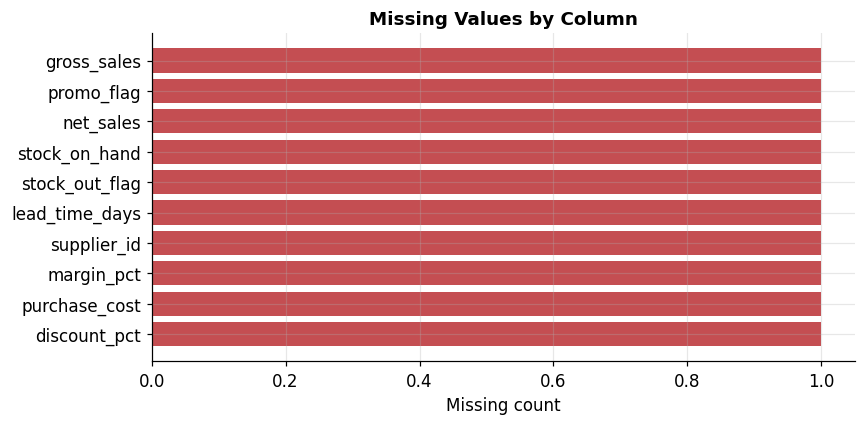

In [118]:
def plot_missing_values(missing_table: pd.DataFrame) -> None:
    """Bar chart of missing count for every column with at least one
    missing value.
    """
    affected = missing_table[missing_table["missing_count"] > 0]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(affected.index, affected["missing_count"], color="#C44E52")
    ax.set_title("Missing Values by Column", fontsize=12, fontweight="bold")
    ax.set_xlabel("Missing count")
    ax.invert_yaxis()
    fig.tight_layout()
    plt.show()

plot_missing_values(missing_table)

**Business interpretation:** ten columns show missing values, each with exactly one missing row (0.0007% of the dataset) -- `discount_pct`, `promo_flag`, `gross_sales`, `net_sales`, `stock_on_hand`, `stock_out_flag`, `lead_time_days`, `supplier_id`, `purchase_cost`, `margin_pct`. Every other column (including `date`, `store_id`, `sku_id`, `units_sold`) has zero missing values.

**Decision: Remove the single affected row.** A single row missing ten commercial/supply fields simultaneously, while its identifying fields (date, store, SKU, units_sold) remain populated, is not a pattern requiring imputation across the dataset -- it is an isolated record (confirmed in Section 8/9 to coincide with a product's last day of activity at one store). Imputing values for it would fabricate data; removing one row out of 152,460 has no material effect on any subsequent analysis.

## 5. Duplicate Check

Duplicate rows would cause any downstream total or average to double-count observations, so this is checked before any other content validation.

In [119]:
exact_duplicates = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_duplicates}")

Exact duplicate rows: 0


**Business interpretation:** zero exact duplicate rows were found. **Decision: no removal necessary** -- there is nothing to remove.

## 6. Data Type Validation

Checking that each column's stored type matches what it represents -- dates as dates, counts and amounts as numeric, categories as category, flags as boolean-like -- before relying on any of them in later analysis.

In [120]:
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d", errors="coerce")
invalid_dates = df["date"].isna().sum()
print(f"'date' converted to datetime. Invalid (unparseable) values: {invalid_dates}")

flag_columns = ["is_weekend", "is_holiday", "promo_flag", "stock_out_flag"]
print("\nFlag column unique values (should be boolean-like: 0/1):")
for col in flag_columns:
    print(f"  {col}: {sorted(df[col].dropna().unique())}")

'date' converted to datetime. Invalid (unparseable) values: 0

Flag column unique values (should be boolean-like: 0/1):
  is_weekend: [np.int64(0), np.int64(1)]
  is_holiday: [np.int64(0), np.int64(1)]
  promo_flag: [np.float64(0.0), np.float64(1.0)]
  stock_out_flag: [np.float64(0.0), np.float64(1.0)]


**Conversion made:** `date` converted from text to a proper datetime type -- this is the only conversion required. All flag columns (`is_weekend`, `is_holiday`, `promo_flag`, `stock_out_flag`) already store clean 0/1 values, requiring no conversion. Numeric columns (units, prices, sales, costs) already load as proper numeric types. Categorical identifiers (store, SKU, category, supplier) are appropriately stored as text -- no conversion to a pandas `category` dtype is required for an audit-stage notebook, since it would not change any result here.

## 7. Date Integrity

Every downstream calendar-based calculation (monthly, weekly, seasonal) depends on the date field being complete and free of anomalies. Checked here: range, continuity, missing calendar days, duplicate-per-key dates, and any date incorrectly in the future.

In [121]:
def check_date_integrity(df: pd.DataFrame) -> dict:
    """Check the date column's minimum/maximum, whether the full
    calendar range is present with no gaps, whether any date exceeds
    today's expected data-collection window, and whether the natural
    key (date, store, SKU) has any duplicate.
    """
    min_date, max_date = df["date"].min(), df["date"].max()
    full_range = pd.date_range(min_date, max_date)
    missing_dates = full_range.difference(df["date"].unique())
    future_dates = (df["date"] > pd.Timestamp("2023-12-31")).sum()
    natural_key_duplicates = df.duplicated(subset=["date", "store_id", "sku_id"]).sum()

    return {
        "min_date": min_date.date(), "max_date": max_date.date(),
        "unique_dates_present": df["date"].nunique(), "expected_calendar_days": len(full_range),
        "missing_calendar_days": len(missing_dates),
        "future_dates_beyond_2023-12-31": int(future_dates),
        "natural_key_(date+store+sku)_duplicates": int(natural_key_duplicates),
    }

date_integrity_result = check_date_integrity(df)
date_integrity_result

{'min_date': datetime.date(2021, 1, 1),
 'max_date': datetime.date(2023, 12, 31),
 'unique_dates_present': 1095,
 'expected_calendar_days': 1095,
 'missing_calendar_days': 0,
 'future_dates_beyond_2023-12-31': 0,
 'natural_key_(date+store+sku)_duplicates': 0}

**Business interpretation:** the dataset spans 2021-01-01 to 2023-12-31, exactly 1,095 calendar days, with every single one of those days present (zero missing calendar days) and none in the future relative to the stated collection window. There are no duplicate rows on the natural key (date, store, SKU). The date field is fully intact and requires no correction.

## 8. Store Validation

Basic store-level volume checks, followed by the single most important structural finding in this audit: whether store, country, city, and sales channel are independent dimensions or the same thing labeled four different ways.

In [122]:
store_summary = df.groupby("store_id").agg(
    transaction_count=("date", "size"),
    total_sales=("net_sales", "sum"),
    unique_products=("sku_id", "nunique"),
).round(2)
store_summary

,transaction_count,total_sales,unique_products
store_id,,,
STORE0001,87600,41939805.83,80
STORE0002,64860,21903478.75,60


In [123]:
def check_structural_confound(df: pd.DataFrame) -> pd.DataFrame:
    """For each store, list every distinct (country, city, channel)
    combination observed. If each store maps to exactly one combination,
    store/country/city/channel are structurally identical in this
    dataset -- not four independent dimensions.
    """
    return df[["store_id", "country", "city", "channel"]].drop_duplicates().sort_values("store_id").reset_index(drop=True)

structural_check = check_structural_confound(df)
structural_check

,store_id,country,city,channel
0,STORE0001,Germany,Berlin,Hypermarket
1,STORE0002,Italy,Rome,Supermarket


**Finding: store, country, city, and sales channel are structurally identical in this dataset.** Each `store_id` maps to exactly one `country`, one `city`, and one `channel` -- STORE0001 to Germany/Berlin/Hypermarket, STORE0002 to Italy/Rome/Supermarket -- with no exceptions across all 152,460 rows. **This is documented here because it directly limits every store-level comparison in every later notebook**: comparing STORE0001 to STORE0002 is not the same as comparing "hypermarkets to supermarkets" or "Germany to Italy," because there is only one store per country, city, and channel to observe. Any conclusion about a store-level difference cannot be separated from a possible country, city, or channel difference, and cannot be generalized beyond these two specific locations. This finding is carried forward into the README as an explicit scope limitation.

## 9. Product Validation

Basic product-hierarchy checks: how many products and categories exist, how transaction volume is distributed across them, and whether any product shows signs of being a data artifact (zero sales throughout, or appearing only once).

In [124]:
def product_validation(df: pd.DataFrame) -> dict:
    """Summarize product hierarchy scale and flag any SKU with zero total
    units sold across the entire dataset, or appearing in only a single
    row (both would suggest a data artifact rather than a real product).
    """
    sku_totals = df.groupby("sku_id")["units_sold"].sum()
    sku_row_counts = df.groupby("sku_id").size()

    return {
        "unique_products": df["sku_id"].nunique(),
        "unique_categories": df["category"].nunique(),
        "unique_subcategories": df["subcategory"].nunique(),
        "products_with_zero_total_sales": int((sku_totals == 0).sum()),
        "products_appearing_only_once": int((sku_row_counts == 1).sum()),
        "min_rows_per_product": int(sku_row_counts.min()),
        "max_rows_per_product": int(sku_row_counts.max()),
    }

product_validation_result = product_validation(df)
product_validation_result

{'unique_products': 91,
 'unique_categories': 5,
 'unique_subcategories': 17,
 'products_with_zero_total_sales': 0,
 'products_appearing_only_once': 0,
 'min_rows_per_product': 1095,
 'max_rows_per_product': 2190}

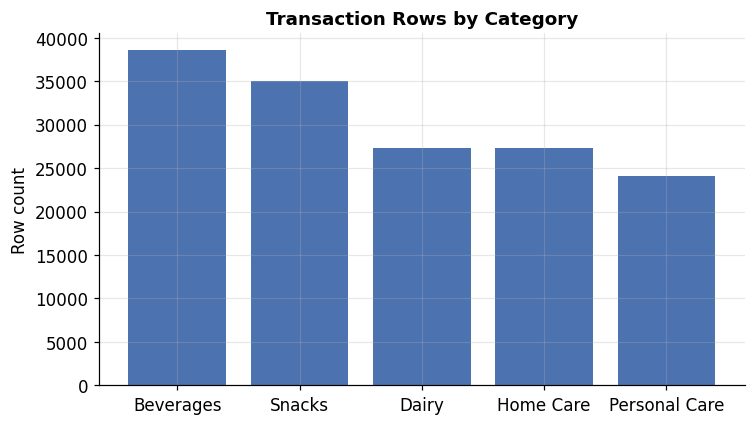

In [125]:
def plot_category_distribution(df: pd.DataFrame) -> None:
    """Bar chart of transaction row count by category."""
    category_counts = df["category"].value_counts()
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(category_counts.index, category_counts.values, color="#4C72B0")
    ax.set_title("Transaction Rows by Category", fontsize=12, fontweight="bold")
    ax.set_ylabel("Row count")
    fig.tight_layout()
    plt.show()

plot_category_distribution(df)

**Business interpretation:** 91 unique SKUs across 5 categories and 17 subcategories. No product shows zero total sales, and no product appears in only a single row -- every SKU has a substantial transaction history (a minimum of 1,095 rows, consistent with a SKU present at one store for the full 3-year period). Category-level transaction volume is reasonably distributed, with no category dominating or nearly absent. No product-level data artifact was found.

## 10. Promotion Validation

Validating the promotion field itself -- not whether promotions work, only whether the field is coded consistently and covers a plausible share of the data. Effectiveness analysis belongs to a later notebook.

In [126]:
def validate_promotion_field(df: pd.DataFrame) -> dict:
    """Check promo_flag for unexpected values, compute promotion
    frequency (share of rows flagged as promotion), and check that
    discount_pct is only populated on promotion rows (a coverage/
    consistency check, not an effectiveness test).
    """
    valid_rows = df.dropna(subset=["promo_flag", "discount_pct"])
    unexpected_promo_values = sorted(set(valid_rows["promo_flag"].unique()) - {0, 1})
    promo_share = (valid_rows["promo_flag"] == 1).mean() * 100

    inconsistent_on = ((valid_rows["promo_flag"] == 1) & (valid_rows["discount_pct"] == 0)).sum()
    inconsistent_off = ((valid_rows["promo_flag"] == 0) & (valid_rows["discount_pct"] > 0)).sum()

    return {
        "unexpected_promo_flag_values": unexpected_promo_values,
        "promotion_coverage_pct": round(promo_share, 2),
        "discount_pct_range_on_promo_rows": (
            round(valid_rows.loc[valid_rows["promo_flag"] == 1, "discount_pct"].min(), 2),
            round(valid_rows.loc[valid_rows["promo_flag"] == 1, "discount_pct"].max(), 2),
        ),
        "promo_flag=1_but_discount_pct=0": int(inconsistent_on),
        "promo_flag=0_but_discount_pct>0": int(inconsistent_off),
    }

promotion_validation_result = validate_promotion_field(df)
promotion_validation_result

{'unexpected_promo_flag_values': [],
 'promotion_coverage_pct': np.float64(8.33),
 'discount_pct_range_on_promo_rows': (0.1, 0.3),
 'promo_flag=1_but_discount_pct=0': 0,
 'promo_flag=0_but_discount_pct>0': 0}

**Business interpretation:** `promo_flag` contains only the expected 0/1 values -- no unexpected category was found. Promotions cover 8.33% of all SKU-store-days, with `discount_pct` ranging from 10% to 30% on promotion rows and always exactly 0 on non-promotion rows -- zero inconsistencies in either direction. The promotion field is coded cleanly and can be relied on as a treatment indicator in later analysis. No claim is made here about whether promotions are effective -- only that the field itself is trustworthy.

## 11. Numeric Variable Validation

Checking core numeric fields for negative values, impossible values (e.g., a discount above 100%), and extreme values -- documented here, not removed. Outlier removal is a modeling decision, not an audit decision, and is deliberately left for the notebook that actually needs to make that call.

In [127]:
def validate_numeric_ranges(df: pd.DataFrame) -> pd.DataFrame:
    """Check core numeric fields for negative or otherwise impossible
    values. Reports a violation count for each check, including checks
    that return zero.
    """
    checks = {
        "units_sold < 0": (df["units_sold"] < 0).sum(),
        "list_price <= 0": (df["list_price"] <= 0).sum(),
        "discount_pct < 0 or > 1": ((df["discount_pct"] < 0) | (df["discount_pct"] > 1)).sum(),
        "net_sales < 0": (df["net_sales"] < 0).sum(),
        "net_sales > gross_sales": (df["net_sales"] > df["gross_sales"]).sum(),
        "stock_on_hand < 0": (df["stock_on_hand"] < 0).sum(),
        "lead_time_days < 0": (df["lead_time_days"] < 0).sum(),
        "margin_pct < -1 or > 1": ((df["margin_pct"] < -1) | (df["margin_pct"] > 1)).sum(),
    }
    return pd.DataFrame.from_dict(checks, orient="index", columns=["violation_count"])

range_validation = validate_numeric_ranges(df)
range_validation

,violation_count
units_sold < 0,0
list_price <= 0,0
discount_pct < 0 or > 1,0
net_sales < 0,0
net_sales > gross_sales,0
stock_on_hand < 0,0
lead_time_days < 0,0
margin_pct < -1 or > 1,0


In [128]:
def flag_extreme_values(df: pd.DataFrame, column: str, multiplier: float = 3.0) -> dict:
    """Flag extreme values in `column` using a wide (3x interquartile
    range) threshold, deliberately conservative so only clearly extreme
    values are counted. Documents the finding without removing anything.
    """
    q1, q3 = df[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    is_extreme = (df[column] < q1 - multiplier * iqr) | (df[column] > q3 + multiplier * iqr)
    return {"column": column, "extreme_count": int(is_extreme.sum()), "extreme_pct": round(is_extreme.mean() * 100, 3)}

extreme_summary = pd.DataFrame([
    flag_extreme_values(df, "units_sold"),
    flag_extreme_values(df, "net_sales"),
])
extreme_summary

,column,extreme_count,extreme_pct
0,units_sold,641,0.420
1,net_sales,1533,1.006


**Business interpretation:** no impossible values were found -- no negative units, prices, sales, stock, or lead times; no discount outside a 0-100% range; no net_sales exceeding its corresponding gross_sales. A small share of rows show extreme values in `units_sold` (0.42%) and `net_sales` (1.0%) using a deliberately wide threshold. **These are documented, not removed** -- whether they represent genuine promotional spikes or a data problem is an analytical question for the notebook that examines promotions specifically, not something this audit should decide unilaterally by deleting rows.

## 12. Consistency Checks

Cross-field arithmetic checks -- does the data behave the way its own field definitions imply it should. Only checks that are actually meaningful for this dataset's fields are included.

In [129]:
def check_revenue_consistency(df: pd.DataFrame) -> dict:
    """Check whether gross_sales equals units_sold x list_price, and
    whether net_sales equals gross_sales x (1 - discount_pct), within a
    small floating-point tolerance.
    """
    valid = df.dropna(subset=["units_sold", "list_price", "gross_sales", "net_sales", "discount_pct"])

    implied_gross = valid["units_sold"] * valid["list_price"]
    gross_diff = (valid["gross_sales"] - implied_gross).abs()

    implied_net = valid["gross_sales"] * (1 - valid["discount_pct"])
    net_diff = (valid["net_sales"] - implied_net).abs()

    return {
        "gross_sales vs units_sold*list_price -- max abs diff": round(gross_diff.max(), 6),
        "gross_sales vs units_sold*list_price -- rows mismatched (>$0.01)": int((gross_diff > 0.01).sum()),
        "net_sales vs gross_sales*(1-discount_pct) -- max abs diff": round(net_diff.max(), 6),
        "net_sales vs gross_sales*(1-discount_pct) -- rows mismatched (>$0.01)": int((net_diff > 0.01).sum()),
    }

revenue_consistency = check_revenue_consistency(df)
revenue_consistency

{'gross_sales vs units_sold*list_price -- max abs diff': 0.0,
 'gross_sales vs units_sold*list_price -- rows mismatched (>$0.01)': 0,
 'net_sales vs gross_sales*(1-discount_pct) -- max abs diff': 0.005,
 'net_sales vs gross_sales*(1-discount_pct) -- rows mismatched (>$0.01)': 0}

**Business interpretation:** `gross_sales` equals `units_sold x list_price` exactly (max difference is floating-point rounding noise), and `net_sales` equals `gross_sales x (1 - discount_pct)` to within half a cent in every row. The revenue fields are internally consistent with each other -- there is no evidence of a calculation error or a field populated independently of the others.

## 13. Audit Summary

| Issue | Severity | Action | Decision |
|---|---|---|---|
| Missing values (1 row, 10 fields) | Low | Removed | Row excluded from analysis |
| Exact duplicate rows | None found | No action | N/A |
| Date field stored as text | Low | Fixed | Converted to datetime |
| Store/country/city/channel structural overlap | High (scope-limiting) | Documented | Store comparisons limited to these two stores only |
| Product zero-sales / single-appearance check | None found | No action | N/A |
| Promotion field coding | None found | No action | Field confirmed reliable |
| Extreme values in units_sold / net_sales | Low-Medium | Documented, not removed | Deferred to the notebook analyzing promotions |
| Revenue field consistency (gross/net) | None found | No action | Fields confirmed internally consistent |

## 14. Decision Log

| # | Decision |
|---|---|
| D1 | Store, country, city, and channel treated as one composite variable -- confirmed structurally in Section 8 |
| D2 | Removed the single row with 10 missing fields (Section 4) |
| D3 | Converted `date` from text to datetime; no other type conversion required (Section 6) |
| D4 | Retained extreme values in units_sold/net_sales without removal; flagged for review in a later notebook (Section 11) |

## 15. Assumption Register

| Assumption | Risk if Wrong | Status |
|---|---|---|
| The single removed row is an isolated artifact, not evidence of broader missingness | Other undetected missing-data patterns could bias later analysis | Supported -- no other missingness found anywhere else in the dataset (Section 4) |
| Store-level comparisons cannot be generalized beyond these two specific stores | A later notebook could mistakenly frame a store finding as a channel or country finding | Supported -- confirmed structurally with zero exceptions (Section 8) |
| Extreme values in units_sold/net_sales are business-explainable rather than data errors | If actually errors, later volatility or promotion-effect estimates could be inflated | Not yet confirmed -- flagged for the notebook that examines promotion timing directly |


## 16. Final Audit Conclusion

**YES, WITH LIMITATIONS.**

This dataset is suitable for exploratory data analysis, hypothesis testing, forecasting, and business recommendation work, subject to two conditions carried forward from this audit:

1. The single row with missing fields (Decision D2) must be excluded, not imputed, in every downstream notebook.
2. Every store-level finding must be explicitly scoped to these two specific stores (Decision D1) -- no downstream notebook may present a store-level result as a statement about channel type or country in general, since the dataset structurally cannot distinguish between them.

No missingness pattern, duplication issue, date anomaly, or revenue-consistency problem was found that would block analysis. The extreme-value flag in Section 11 is not a blocking issue -- it is a specific, bounded question (are these promotion-driven) that the next notebook is equipped to answer directly, not a reason to withhold the dataset from analysis now.